In [1]:
#import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
DATA_PATH = Path("../data/raw/dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset introuvable. Consultez le README pour le télécharger."
    )

df = pd.read_csv(DATA_PATH)

Le CNN est choisi lorsque les données possèdent une structure spatiale locale. Le RNN est choisi lorsque l'ordre des obervations est important (série temporelle, texte..).
Le MLP est adapté lorsque les données sont des vecteurs de caractéristiques sans structures spatiale ou temporelle particulère.
Donc ici avec le dataset telco customer churn on devrait choisir un MLP, car les donées sont des vecteurs sans structures spatiales ou temporelles. 

In [3]:
# Entraînement d'un modèle de MLP 
# Variable cible
y = df['Churn'].map({'Yes':1, 'No':0})

# Suppression des colonnes inutiles
X = df.drop(['customerID', 'Churn'], axis=1)

# Conversion de TotalCharges
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X = X.fillna(X.median(numeric_only=True))

# Encodage
X = pd.get_dummies(X, drop_first=True)

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)   

# Mise à l'échelle des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(random_state=42, max_iter=500)
mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)
print("Accuracy MLP :", accuracy_score(y_test, mlp_pred))
print('confusion_matrix MLP :\n', confusion_matrix(y_test, mlp_pred
))

Accuracy MLP : 0.7665010645848119
confusion_matrix MLP :
 [[882 153]
 [176 198]]


In [4]:
# Recherche des meilleurs hyperparamètres pour le MLP
from sklearn.model_selection import GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}
grid_search = GridSearchCV(MLPClassifier(random_state=42, max_iter=500), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
best_mlp = grid_search.best_estimator_
best_mlp_pred = best_mlp.predict(X_test_scaled)
print("Accuracy Best MLP :", accuracy_score(y_test, best_mlp_pred))
print('confusion_matrix Best MLP :\n', confusion_matrix(y_test, best_mlp_pred))


Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,)}
Accuracy Best MLP : 0.7750177430801988
confusion_matrix Best MLP :
 [[885 150]
 [167 207]]


In [5]:
# Choix de l'optimiseur
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred = log_reg.predict(X_test_scaled)
print("Accuracy Logistic Regression :", accuracy_score(y_test, log_reg_pred))
print('confusion_matrix Logistic Regression :\n', confusion_matrix(y_test, log_reg_pred))


Accuracy Logistic Regression : 0.8069552874378992
confusion_matrix Logistic Regression :
 [[925 110]
 [162 212]]


In [6]:
# strategie explicite pour lutter contre le vanishing et exploding gradient
from sklearn.neural_network import MLPClassifier
mlp_explicit = MLPClassifier(random_state=42, max_iter=500, hidden_layer_sizes=(100,), activation='relu', alpha=0.001)
mlp_explicit.fit(X_train_scaled, y_train)
mlp_explicit_pred = mlp_explicit.predict(X_test_scaled)
print("Accuracy MLP Explicit :", accuracy_score(y_test, mlp_explicit_pred))
print('confusion_matrix MLP Explicit :\n', confusion_matrix(y_test, mlp_explicit_pred))



Accuracy MLP Explicit : 0.772888573456352
confusion_matrix MLP Explicit :
 [[897 138]
 [182 192]]


Comparaison des modèles:
                        Model  Accuracy
0                MLP Baseline  0.766501
1  MLP Optimized (GridSearch)  0.775018
2         Logistic Regression  0.806955
3                MLP Explicit  0.772889


Matrice de confusion - MLP Baseline:
[[882 153]
 [176 198]]

Matrice de confusion - MLP Optimized:
[[885 150]
 [167 207]]

Matrice de confusion - Logistic Regression:
[[925 110]
 [162 212]]

Matrice de confusion - MLP Explicit:
[[897 138]
 [182 192]]


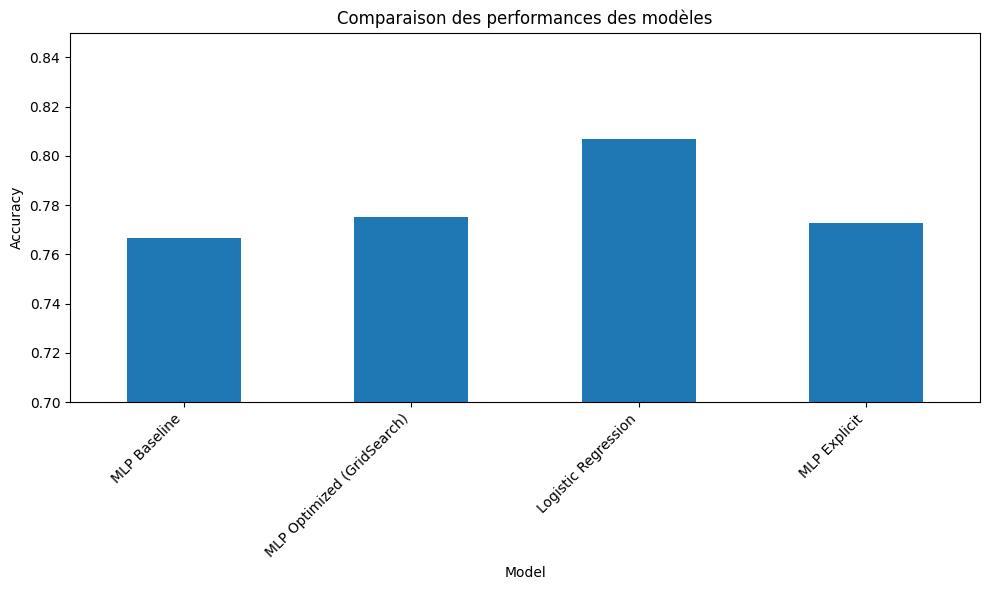

In [7]:
# Créer un tableau comparatif des performances des modèles
results_comparison = pd.DataFrame({
    'Model': ['MLP Baseline', 'MLP Optimized (GridSearch)', 'Logistic Regression', 'MLP Explicit'],
    'Accuracy': [
        accuracy_score(y_test, mlp_pred),
        accuracy_score(y_test, best_mlp_pred),
        accuracy_score(y_test, log_reg_pred),
        accuracy_score(y_test, mlp_explicit_pred)
    ]
})

print("Comparaison des modèles:")
print(results_comparison)
print("\n" + "="*60 + "\n")

# Afficher les matrices de confusion
print("Matrice de confusion - MLP Baseline:")
print(confusion_matrix(y_test, mlp_pred))
print("\nMatrice de confusion - MLP Optimized:")
print(confusion_matrix(y_test, best_mlp_pred))
print("\nMatrice de confusion - Logistic Regression:")
print(confusion_matrix(y_test, log_reg_pred))
print("\nMatrice de confusion - MLP Explicit:")
print(confusion_matrix(y_test, mlp_explicit_pred))

# Visualiser les résultats
fig, ax = plt.subplots(figsize=(10, 6))
results_comparison.plot(x='Model', y='Accuracy', kind='bar', ax=ax, legend=False)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
ax.set_title('Comparaison des performances des modèles')
ax.set_ylim([0.7, 0.85])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Analyse critique et arguementation sur les résultats obtenus en comparant les performances, limites et temps de calcul entre les différents modèles testés. Discussion sur les choix d'hyperparamètres et leur impact sur les résultats.

In [9]:
%%markdown
Analyse critique des résultats

- Logistic Regression a obtenu la meilleure précision sur le jeu de test (≈0.807), ce qui suggère que le problème est bien capté par un modèle linéaire sur ces caractéristiques normalisées.
- Le MLP de base (≈0.767) et le MLP explicite (≈0.773) restent en dessous, ce qui indique que le réseau n’apporte pas de gain significatif pour ce jeu de données tabulaire.
- La recherche de grille a permis une légère amélioration du MLP (≈0.775), mais pas suffisamment pour dépasser la régression logistique.
- Impact des hyperparamètres :
    - `hidden_layer_sizes` : le meilleur modèle trouvé utilise une architecture simple `(50,)`, ce qui montre qu’un réseau plus profond n’est pas forcément nécessaire ici.
    - `activation='relu'` : cette fonction d’activation est bien adaptée à la convergence du MLP dans ce cas.
    - `alpha=0.01` : une régularisation plus forte a aidé à mieux généraliser et à limiter le surapprentissage.
- Limites et temps de calcul :
    - `GridSearchCV` est coûteux en temps, surtout pour des MLP avec plusieurs configurations. Le gain de performance obtenu reste faible par rapport à ce coût.
    - La régression logistique est beaucoup plus rapide à entraîner et plus stable.
    - Les MLP nécessitent une mise à l’échelle stricte et restent sensibles aux choix d’architecture et à la régularisation.
- Conclusion :
    - Pour le dataset Telco Customer Churn, la régression logistique est le meilleur modèle parmi ceux testés.
    - Le MLP peut rester une option, mais il faut privilégier des architectures simples et une régularisation adéquate.
    - D’autres métriques comme precision, recall ou F1-score, ainsi que des techniques d’équilibrage des classes ou de sélection de variables, seraient utiles pour affiner l’analyse.

Analyse critique des résultats

- Logistic Regression a obtenu la meilleure précision sur le jeu de test (≈0.807), ce qui suggère que le problème est bien capté par un modèle linéaire sur ces caractéristiques normalisées.
- Le MLP de base (≈0.767) et le MLP explicite (≈0.773) restent en dessous, ce qui indique que le réseau n’apporte pas de gain significatif pour ce jeu de données tabulaire.
- La recherche de grille a permis une légère amélioration du MLP (≈0.775), mais pas suffisamment pour dépasser la régression logistique.
- Impact des hyperparamètres :
    - `hidden_layer_sizes` : le meilleur modèle trouvé utilise une architecture simple `(50,)`, ce qui montre qu’un réseau plus profond n’est pas forcément nécessaire ici.
    - `activation='relu'` : cette fonction d’activation est bien adaptée à la convergence du MLP dans ce cas.
    - `alpha=0.01` : une régularisation plus forte a aidé à mieux généraliser et à limiter le surapprentissage.
- Limites et temps de calcul :
    - `GridSearchCV` est coûteux en temps, surtout pour des MLP avec plusieurs configurations. Le gain de performance obtenu reste faible par rapport à ce coût.
    - La régression logistique est beaucoup plus rapide à entraîner et plus stable.
    - Les MLP nécessitent une mise à l’échelle stricte et restent sensibles aux choix d’architecture et à la régularisation.
- Conclusion :
    - Pour le dataset Telco Customer Churn, la régression logistique est le meilleur modèle parmi ceux testés.
    - Le MLP peut rester une option, mais il faut privilégier des architectures simples et une régularisation adéquate.
    - D’autres métriques comme precision, recall ou F1-score, ainsi que des techniques d’équilibrage des classes ou de sélection de variables, seraient utiles pour affiner l’analyse.
